Classify area bin using KNN.
First import libraries and data set.

In [9]:
import pandas as pd
import numpy as np
from numpy import *
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, classification_report
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns
import sys

df = pd.read_csv("data/forestfires.csv")
y_label = 'area_bin'
df

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00


Some feature engineering, which include:
1. label encoding month and day column
2. take the log of area column
3. cutting the area target into 6 bins

In [5]:
df_pre = df.copy()
df_pre['month'] = df_pre['month'].astype('category').cat.codes
df_pre['day'] = df_pre['day'].astype('category').cat.codes
df_pre['area'] = ma.log(df_pre['area'].values).filled(0)
area_labels = [1, 2, 3, 4, 5, 6]
df_pre['area_bin'] = pd.cut(df_pre['area'], include_lowest=True, bins=6, labels=area_labels)
df_pre.drop(columns=['area'], inplace=True)
df_pre

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area_bin
0,7,5,7,0,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,2
1,7,4,10,5,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,2
2,7,4,10,2,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,2
3,8,6,7,0,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,2
4,8,6,7,3,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,1,3,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,3
513,2,4,1,3,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,5
514,7,4,1,3,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,4
515,1,4,1,2,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,2


Oversample the dataset using SMOTE

In [6]:
from imblearn.over_sampling import SMOTE, ADASYN
from tensorflow.keras import backend as k
df_x = df_pre.drop(columns=[y_label])
df_y = df_pre[y_label]
oversample = ADASYN(sampling_strategy='all', n_neighbors=2)
df_x_smote, df_y_smote = oversample.fit_resample(df_x, df_y)
df_y_smote

0       2
1       2
2       2
3       2
4       2
       ..
1805    6
1806    6
1807    6
1808    6
1809    6
Name: area_bin, Length: 1810, dtype: category
Categories (6, int64): [1 < 2 < 3 < 4 < 5 < 6]

70-30 split the dataset for training and testing 

In [7]:
x_train, x_test, y_train, y_test = train_test_split(df_x, df_y, test_size=0.3, random_state=1)
x_train_smote, x_test_smote, y_train_smote, y_test_smote = train_test_split(df_x_smote, df_y_smote, test_size=0.3, random_state=1)
y_test.value_counts()

2    95
3    31
4    19
5     7
1     3
6     1
Name: area_bin, dtype: int64

Self-implement two functions to calculate sensitivity and specificity.

In [8]:
def get_sensitivity(cm, label):
    labels = [1,2,3,4,5,6]
    #cm = confusion_matrix(y_test, y_pred, labels=labels)
    #print("{}/{}".format(cm[label - 1, label - 1], sum(cm[label - 1])))
    return cm[label - 1, label - 1] / sum(cm[label - 1])

def get_specificity(cm, label):
    indexes = [0,1,2,3,4,5]
    #cm = confusion_matrix(y_test, y_pred, labels=[1,2,3,4,5,6])
    tn = sum(np.diag(cm)) - cm[label - 1, label - 1]
    fp = sum([cm[i][label - 1] for i in indexes]) - cm[label - 1, label - 1]
    #print("tn:{}, fp:{}".format(tn, fp))
    return tn / (tn + fp)

def display_sens_spec(y_pred, y_test):
    labels = [1,2,3,4,5,6]
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    result = pd.DataFrame(columns=['label', 'sensitivity', 'specificity'])
    for idx, label in enumerate(labels):
        result.loc[idx] = [label, get_sensitivity(cm, label), get_specificity(cm, label)]
    result.set_index('label', inplace=True)
    return result    

Use the K Nearest Neighbor algorithm to classify area bin. First try to set the K to 5 on the original dataset(without oversampling), which reached an accuracy of .50

In [11]:
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(x_train, y_train)
y_pred = knn_clf.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred, labels=[1,2,3,4,5,6]))
print(display_sens_spec(y_pred, y_test))

Accuracy: 0.5
[[ 0  2  1  0  0  0]
 [ 3 73 18  1  0  0]
 [ 1 25  5  0  0  0]
 [ 0 17  2  0  0  0]
 [ 0  5  2  0  0  0]
 [ 0  1  0  0  0  0]]
       sensitivity  specificity
label                          
1.0       0.000000     0.951220
2.0       0.768421     0.090909
3.0       0.161290     0.760417
4.0       0.000000     0.987342
5.0       0.000000     1.000000
6.0       0.000000     1.000000


Try setting K to be 5 on the oversampled dataset. It reached an accuracy of .74.

In [12]:
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(x_train_smote, y_train_smote)
y_pred = knn_clf.predict(x_test_smote)
print("Accuracy:", accuracy_score(y_test_smote, y_pred))
print(confusion_matrix(y_test_smote, y_pred, labels=[1,2,3,4,5,6]))
print(display_sens_spec(y_pred, y_test_smote))

Accuracy: 0.7403314917127072
[[92  0  2  0  0  3]
 [ 7 28 24 19 16  3]
 [ 4 16 42 10  0  6]
 [ 1  3  7 74  1  0]
 [ 1  4  4  5 92  0]
 [ 0  3  1  1  0 74]]
       sensitivity  specificity
label                          
1.0       0.948454     0.959752
2.0       0.288660     0.935000
3.0       0.538462     0.904523
4.0       0.860465     0.903581
5.0       0.867925     0.948012
6.0       0.936709     0.964706


Try to detect the effect of different K options.

Accuracy with n_neighbors 1: 0.391025641025641
Accuracy with n_neighbors 2: 0.47435897435897434
Accuracy with n_neighbors 3: 0.4423076923076923
Accuracy with n_neighbors 4: 0.5
Accuracy with n_neighbors 5: 0.5
Accuracy with n_neighbors 6: 0.5384615384615384
Accuracy with n_neighbors 7: 0.5256410256410257
Accuracy with n_neighbors 8: 0.5128205128205128
Accuracy with n_neighbors 9: 0.532051282051282
Accuracy with n_neighbors 10: 0.5384615384615384
Accuracy with n_neighbors 11: 0.5641025641025641
Accuracy with n_neighbors 12: 0.5512820512820513
Accuracy with n_neighbors 13: 0.5512820512820513
Accuracy with n_neighbors 14: 0.5769230769230769
Accuracy with n_neighbors 15: 0.5384615384615384
Accuracy with n_neighbors 16: 0.5641025641025641
Accuracy with n_neighbors 17: 0.5641025641025641
Accuracy with n_neighbors 18: 0.5769230769230769
Accuracy with n_neighbors 19: 0.5769230769230769
Accuracy with n_neighbors 20: 0.5897435897435898
Accuracy with n_neighbors 21: 0.5961538461538461
Accuracy wi

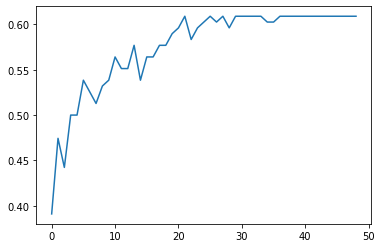

In [31]:
accuracies = []
for n in range(1, 50):
    knn_clf = KNeighborsClassifier(n_neighbors=n)
    knn_clf.fit(x_train, y_train)
    y_pred = knn_clf.predict(x_test)
    acc_score = accuracy_score(y_test, y_pred)
    accuracies.append(acc_score)
    print("Accuracy with n_neighbors {}: {}".format(n, acc_score))
plt.plot(accuracies)
plt.show()

For the original dataset, accuracy improves as K grows, up until to around 22 where accuracy stops increasing.

Accuracy with n_neighbors 1: 0.8360957642725598
Accuracy with n_neighbors 2: 0.8011049723756906
Accuracy with n_neighbors 3: 0.7863720073664825
Accuracy with n_neighbors 4: 0.7697974217311234
Accuracy with n_neighbors 5: 0.7403314917127072
Accuracy with n_neighbors 6: 0.7274401473296501
Accuracy with n_neighbors 7: 0.7182320441988951
Accuracy with n_neighbors 8: 0.6906077348066298
Accuracy with n_neighbors 9: 0.6795580110497238
Accuracy with n_neighbors 10: 0.6721915285451197
Accuracy with n_neighbors 11: 0.6611418047882136
Accuracy with n_neighbors 12: 0.6648250460405156
Accuracy with n_neighbors 13: 0.6629834254143646
Accuracy with n_neighbors 14: 0.6556169429097606
Accuracy with n_neighbors 15: 0.6500920810313076
Accuracy with n_neighbors 16: 0.6372007366482505
Accuracy with n_neighbors 17: 0.6372007366482505
Accuracy with n_neighbors 18: 0.6408839779005525
Accuracy with n_neighbors 19: 0.6279926335174953
Accuracy with n_neighbors 20: 0.6279926335174953
Accuracy with n_neighbors 21:

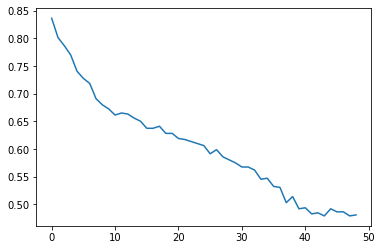

In [34]:
accuracies = []
for n in range(1, 50):
    knn_clf = KNeighborsClassifier(n_neighbors=n)
    knn_clf.fit(x_train_smote, y_train_smote)
    y_pred = knn_clf.predict(x_test_smote)
    acc_score = accuracy_score(y_test_smote, y_pred)
    accuracies.append(acc_score)
    print("Accuracy with n_neighbors {}: {}".format(n, acc_score))
plt.plot(accuracies)

It's interesting that, for the oversampled data set, accuracy decreased as K grows. I think it's due to the fact that, SMOTE oversampling adds more points alongside the line between two minority class points, thus enabling larger K would take into consideration more points out of the SMOTE line which belongs to other class, thus diminishing the accuracy for minority class samples.

In [35]:
knn_clf = KNeighborsClassifier(n_neighbors=1)
knn_clf.fit(x_train_smote, y_train_smote)
y_pred = knn_clf.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred, labels=[1,2,3,4,5,6]))
print(display_sens_spec(y_pred, y_test))

Accuracy: 0.8461538461538461
[[ 3  0  0  0  0  0]
 [ 4 73 10  4  3  1]
 [ 0  1 30  0  0  0]
 [ 0  1  0 18  0  0]
 [ 0  0  0  0  7  0]
 [ 0  0  0  0  0  1]]
       sensitivity  specificity
label                          
1.0       1.000000     0.969925
2.0       0.768421     0.967213
3.0       0.967742     0.910714
4.0       0.947368     0.966102
5.0       1.000000     0.976562
6.0       1.000000     0.992424


Setting K to be 1 on the oversampled dataset would achieve an accuracy of .846.

In [37]:
knn_1 = KNeighborsClassifier(n_neighbors=1)
knn_1.fit(x_train_smote, y_train_smote)
y_pred = knn_1.predict(x_test_smote)
acc = accuracy_score(y_test_smote, y_pred)
print("Accuracy:", acc)
print(confusion_matrix(y_test_smote, y_pred, labels=[1,2,3,4,5,6]))
print(display_sens_spec(y_pred, y_test_smote))

Accuracy: 0.8360957642725598
[[ 93   0   1   0   0   3]
 [  5  37  22  17  13   3]
 [  1   6  66   4   0   1]
 [  0   1   2  81   2   0]
 [  0   5   0   0 101   0]
 [  0   1   2   0   0  76]]
       sensitivity  specificity
label                          
1.0       0.958763     0.983651
2.0       0.381443     0.969767
3.0       0.846154     0.934940
4.0       0.941860     0.946701
5.0       0.952830     0.959239
6.0       0.962025     0.981818


In [38]:
knn_10 = KNeighborsClassifier(n_neighbors=10)
knn_10.fit(x_train_smote, y_train_smote)
y_pred = knn_10.predict(x_test_smote)
acc = accuracy_score(y_test_smote, y_pred)
print("Accuracy:", acc)
print(confusion_matrix(y_test_smote, y_pred, labels=[1,2,3,4,5,6]))
print(display_sens_spec(y_pred, y_test_smote))

Accuracy: 0.6721915285451197
[[92  1  1  0  0  3]
 [10 23 18 23 17  6]
 [ 5  7 26 24  2 14]
 [ 2  3  6 70  4  1]
 [ 5  4  9  7 78  3]
 [ 0  0  2  0  1 76]]
       sensitivity  specificity
label                          
1.0       0.948454     0.925424
2.0       0.237113     0.957983
3.0       0.333333     0.904000
4.0       0.813953     0.845272
5.0       0.735849     0.922830
6.0       0.962025     0.914557
